In [29]:
import os
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import tifffile

from pathlib import Path


In [44]:
# vol_folder = r'D:\NMAR\test_01\nmar_vol'
# mask_path = r'D:\NMAR\Case_01_Deliverables\metal_mask\metal_mask.npy'
raw_dcm_path = r"D:\NMAR\Case_02_MFOV_Foot\2.16.840.114490.20251103153455\2.16.840.114490.20251103153455.896634811036079469160819174862852"
metal_trace_path = r"D:\NMAR\Case_02_Deliverables\metal_mask\metal_mask.npy"

root_output_dir = Path(r'D:\NMAR\Case_02_Deliverables')

li_dir = root_output_dir / "linear_interp"
os.makedirs(li_dir, exist_ok=True)

In [45]:
def interp_1d_over_mask(signal_1d, mask_1d):
    out = signal_1d.copy()
    metal_idx = np.where(mask_1d)[0]
    nonmetal_idx = np.where(~mask_1d)[0]

    if len(metal_idx) == 0:
        return out
    if len(nonmetal_idx) < 2:
        return out

    out[metal_idx] = np.interp(metal_idx, nonmetal_idx, signal_1d[nonmetal_idx])
    return out

def interp_proj_stack(proj, metal_trace):
    out = proj.copy()
    num_views, det_rows, _ = proj.shape

    for v in range(num_views):
        for r in range(det_rows):
            out[v, r] = interp_1d_over_mask(proj[v, r], metal_trace[v, r])
    return out

def load_raw_projection_dicom(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    raw_proj = ds.pixel_array.astype(np.float32)
    return ds, raw_proj


raw_proj shape: (720, 768, 1024)
metal_trace: (720, 768, 1024)


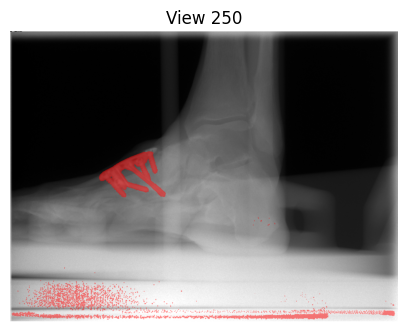

In [49]:
ds, raw_proj = load_raw_projection_dicom(raw_dcm_path)
print("raw_proj shape:", raw_proj.shape)

# metal_trace = tifffile.imread(metal_trace_path)
metal_trace = np.load(metal_trace_path)
# metal_trace = (metal_trace > 0).astype(np.float32)
metal_trace = (metal_trace > 0).astype(bool)
# metal_trace = (metal_trace > 0)
# metal_trace = metal_trace.transpose(0, 2, 1)
print("metal_trace:", metal_trace.shape)
I = raw_proj.astype(np.float32)
I0 = np.percentile(I, 99.0)
proj_log = -np.log(np.clip(I / I0, 1e-6, None))

v = 250
raw = proj_log[v] if 'proj_log' in locals() else raw_proj[v]
mask = metal_trace[v]
        # mask = mask_trace[v]
        # mask = metal_trace_fixed[v]
        # mask = metal_trace[(v - shift) % proj_log.shape[0]]

p1, p99 = np.percentile(raw, (1, 99))
raw_norm = np.clip((raw - p1) / (p99 - p1 + 1e-6), 0, 1)

rgb = np.stack([raw_norm, raw_norm, raw_norm], axis=-1)

alpha = 0.5
rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])
rgb[..., 1] = np.where(mask, (1 - alpha) * rgb[..., 1], rgb[..., 1])
rgb[..., 2] = np.where(mask, (1 - alpha) * rgb[..., 2], rgb[..., 2])

plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title(f"View {v}")
plt.axis("off")
plt.show()


proj_log.shape:  (720, 768, 1024)
metal_trace.shape:  (720, 768, 1024)
<class 'numpy.ndarray'> (720, 768, 1024)


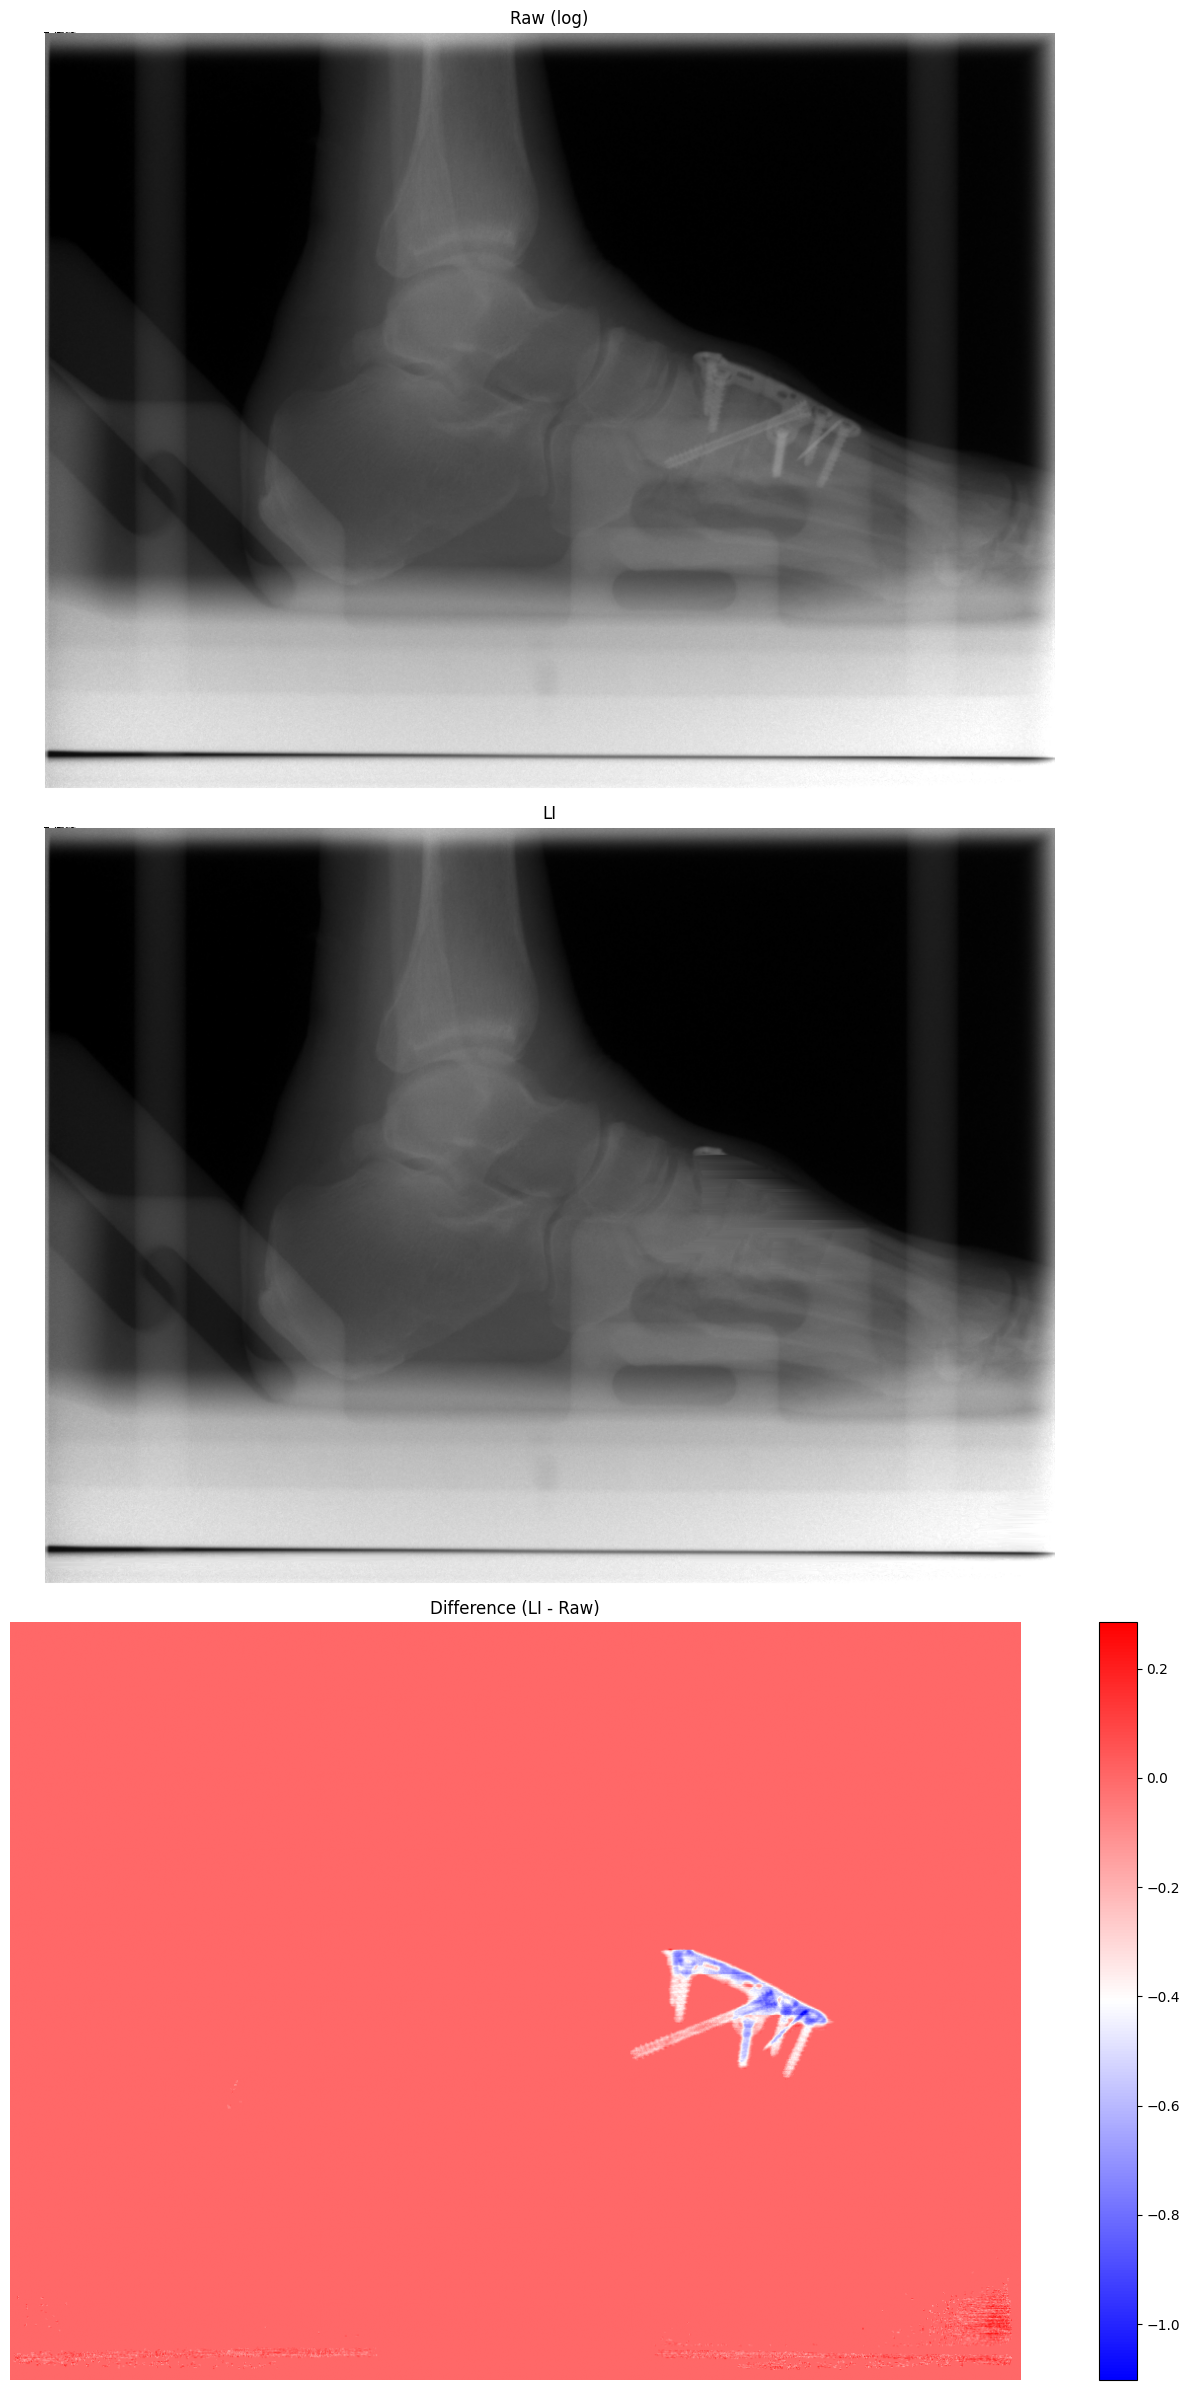

Saved: D:\NMAR\Case_02_Deliverables\linear_interp\proj_li_debug_view_719.png


In [54]:
print("proj_log.shape: ", proj_log.shape)
print("metal_trace.shape: ", metal_trace.shape)

# metal_trace = (metal_trace > 0).astype(np.float32)

proj_li = interp_proj_stack(proj_log, metal_trace)
np.save(os.path.join(li_dir, "proj_li.npy"), proj_li)
print(type(proj_li), proj_li.shape)

# pick a representative projection
v = proj_log.shape[0] // 1 -1

raw = proj_log[v]
li  = proj_li[v]
diff = li - raw

# normalize for display
def normalize(x):
    p1, p99 = np.percentile(x, (1, 99))
    return np.clip((x - p1) / (p99 - p1 + 1e-6), 0, 1)

raw_n = normalize(raw)
li_n  = normalize(li)

plt.figure(figsize=(16, 24))

plt.subplot(3, 1, 1)
plt.title("Raw (log)")
plt.imshow(raw_n, cmap='gray')
plt.axis('off')

plt.subplot(3, 1, 2)
plt.title("LI")
plt.imshow(li_n, cmap='gray')
plt.axis('off')

plt.subplot(3, 1, 3)
plt.title("Difference (LI - Raw)")
plt.imshow(diff, cmap='bwr')
plt.colorbar()
plt.axis('off')

plt.tight_layout()

# save
out_path = os.path.join(li_dir, f"proj_li_debug_view_{v}.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"Saved: {out_path}")

## Not Using


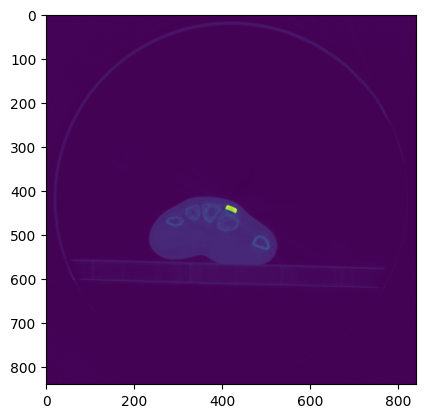

In [12]:
def load_dicom_series_hu(folder):
    slices = []

    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        try:
            ds = pydicom.dcmread(path)
            slices.append(ds)
        except:
            continue

    # sort slices (important)
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

    # stack raw pixel data
    vol = np.stack([s.pixel_array for s in slices]).astype(np.float32)

    # apply HU scaling
    slope = getattr(slices[0], "RescaleSlope", 1.0)
    intercept = getattr(slices[0], "RescaleIntercept", 0.0)

    vol_hu = vol * slope + intercept
    return vol_hu, slices

# ---- usage ----
# folder = "path/to/dicom_dir"
vol_hu, slices = load_dicom_series_hu(vol_folder)


z = vol_hu.shape[0] // 2
plt.imshow(vol_hu[z])